In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
def load_combined_data(og_dir, retrain_dir):
    og_dfs = []
    retrain_dfs = []
    
    # Load original data
    og_path = Path(og_dir)
    for ckpt_dir in og_path.glob("ckpt_*"):
        if "to" in ckpt_dir.name:
            continue
        
        for summary_file in ckpt_dir.glob("fast_eval_*/summary.tsv"):
            df = pd.read_csv(summary_file, sep="\t")
            step = ckpt_dir.name.replace("ckpt_", "")
            df["step"] = step
            df["config"] = "original"
            og_dfs.append(df)
        
    # Load retrained data
    retrain_path = Path(retrain_dir)
    for ckpt_dir in retrain_path.glob("ckpt_*"):
        if "to" in ckpt_dir.name:
            continue
        
        for summary_file in ckpt_dir.glob("fast_eval_*/summary.tsv"):
                df = pd.read_csv(summary_file, sep='\t')
                step = ckpt_dir.name.replace("ckpt_", "")
                df["step"] = step
                df["config"] = "retrained"
                retrain_dfs.append(df)
        
    # Combine all data
    combined_df = pd.concat(og_dfs + retrain_dfs, ignore_index=True)
    return combined_df

In [15]:
# Load data
og_dir = "/data/ratna/eval_results"
retrain_dir = "/data/ratna_retrain/eval_results"
combined_df = load_combined_data(og_dir, retrain_dir)
combined_df.head()

,dataset,mode,status,elapsed_sec,metric,metric_mean,runs,start,end,results_json,log_file,step,config
0,bach,predict_fit,ok,297,val/MulticlassAccuracy,0.648607,"run_1=0.649128, run_2=0.648086",2026-03-02T01:38:37+00:00,2026-03-02T01:43:34+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
1,bracs,predict_fit,ok,421,test/MulticlassAccuracy,0.538691,"run_1=0.542636, run_2=0.534745",2026-03-02T01:43:35+00:00,2026-03-02T01:50:36+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
2,breakhist,predict_fit,ok,275,val/MulticlassAccuracy,0.774133,"run_1=0.770730, run_2=0.777537",2026-03-02T01:50:36+00:00,2026-03-02T01:55:11+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
3,crc,predict_fit,ok,1745,val/MulticlassAccuracy,0.887309,"run_1=0.885296, run_2=0.889322",2026-03-02T01:55:11+00:00,2026-03-02T02:24:16+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
4,gleason,predict_fit,ok,470,val/MulticlassAccuracy,0.665182,"run_1=0.666442, run_2=0.663922",2026-03-02T02:24:16+00:00,2026-03-02T02:32:06+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original


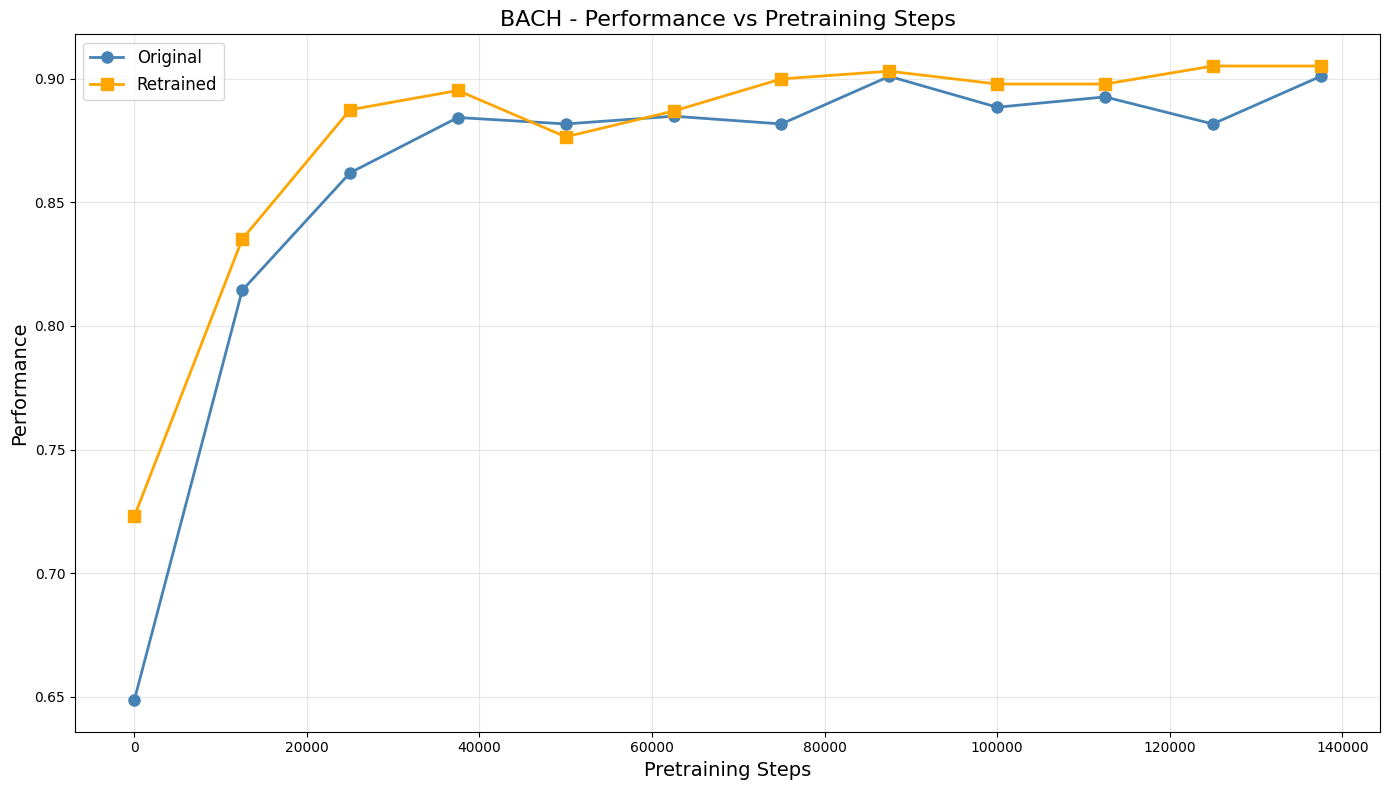

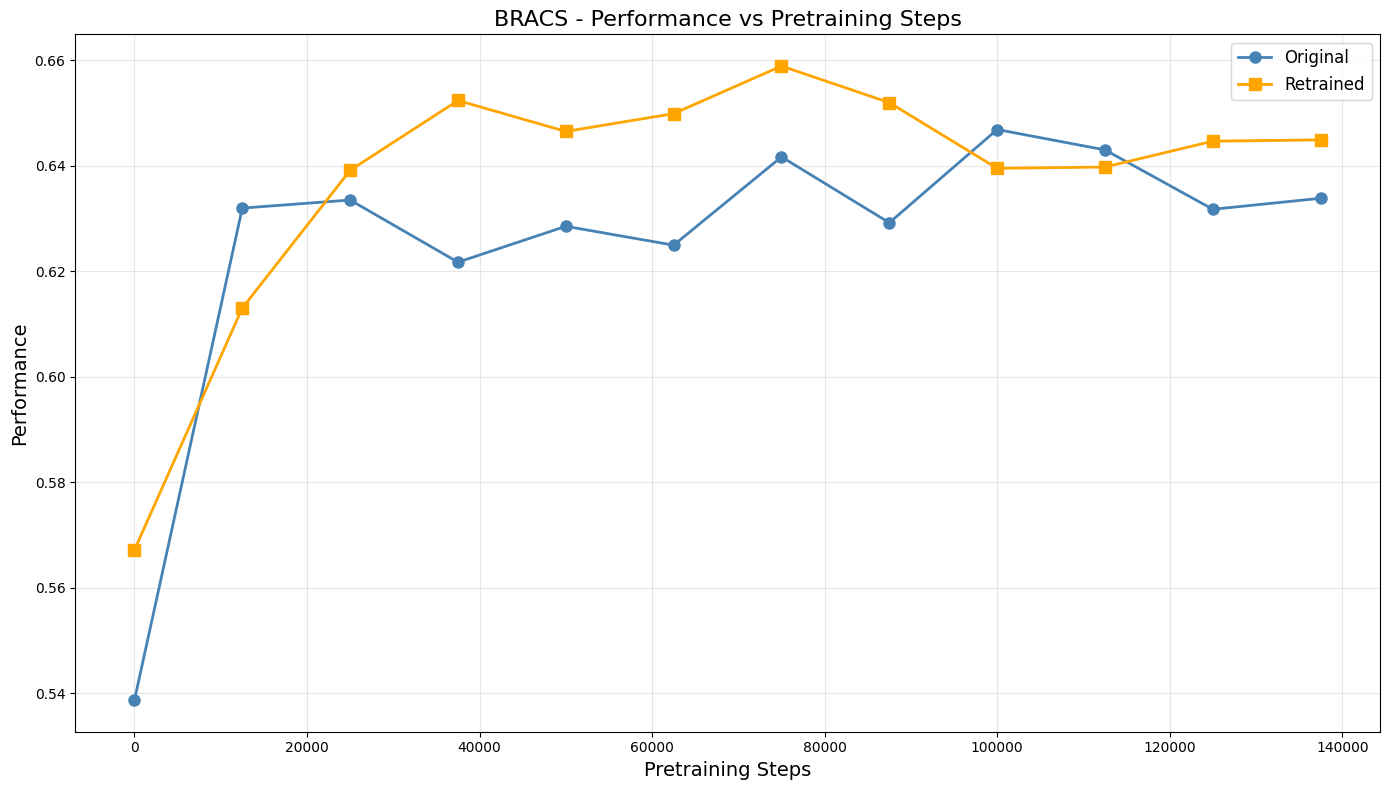

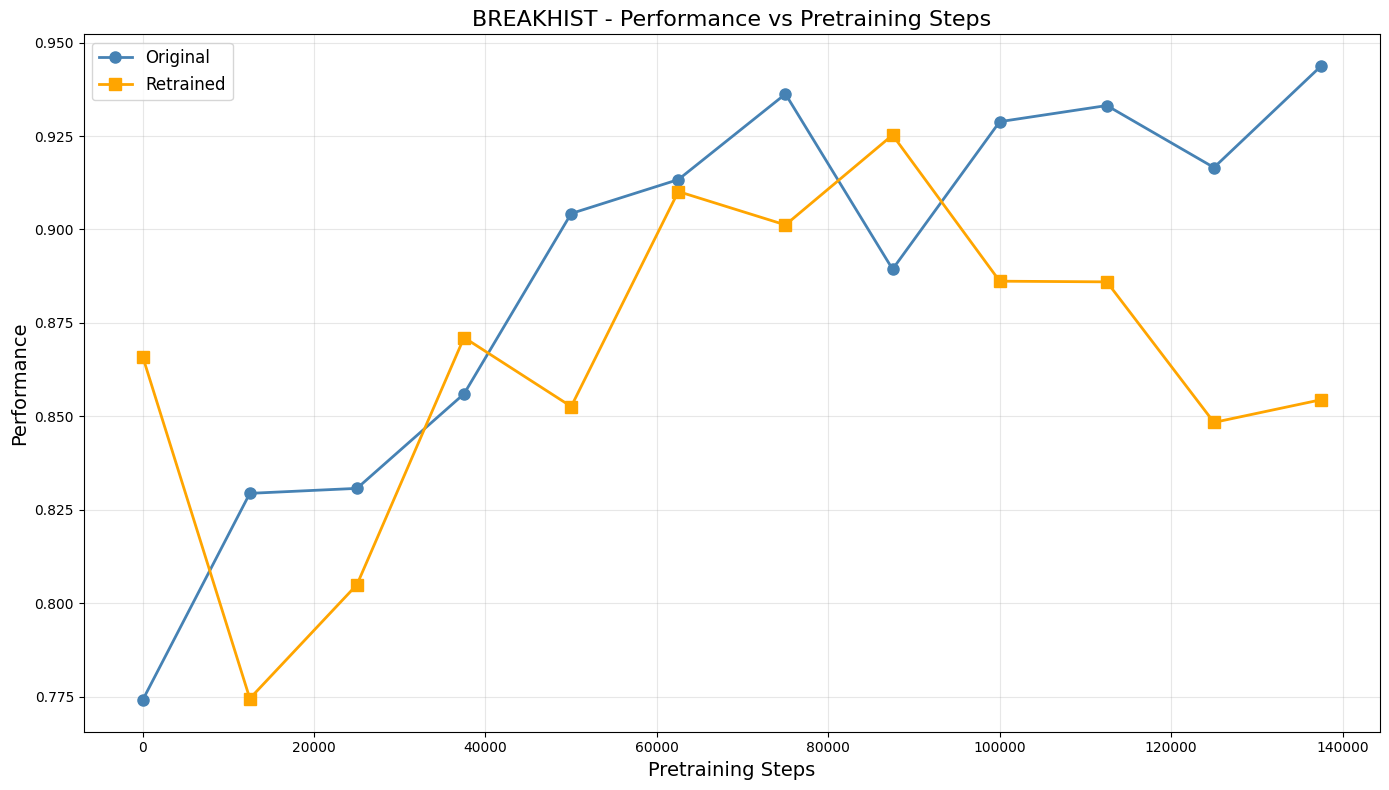

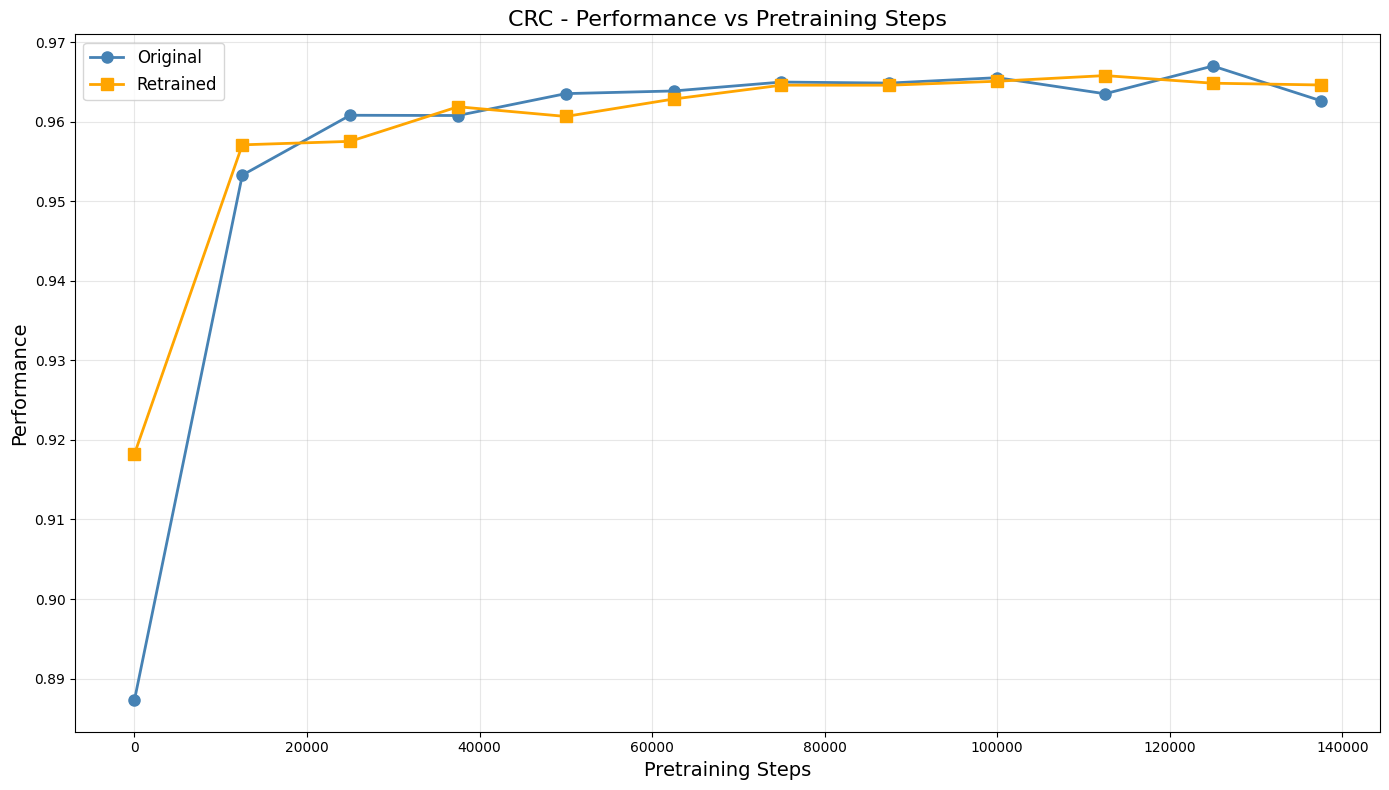

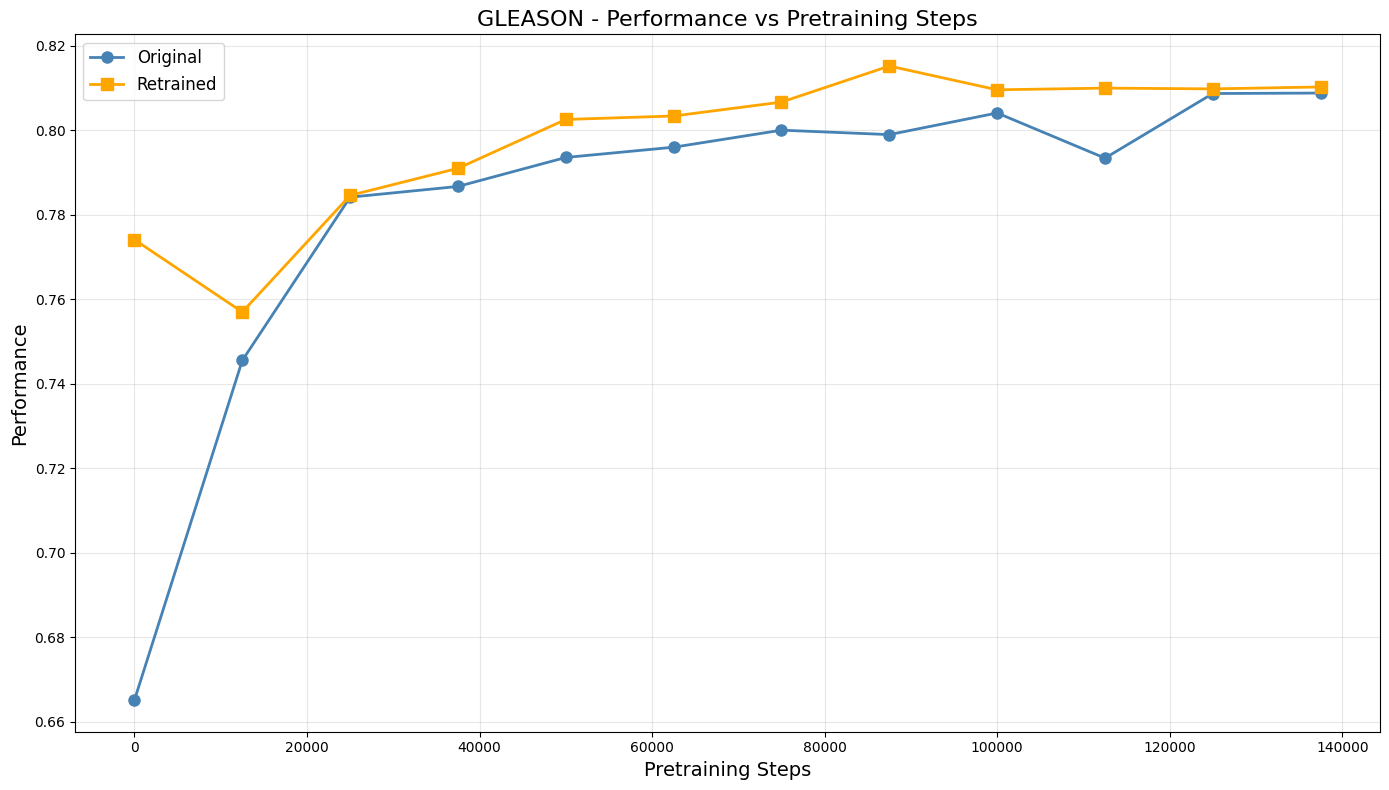

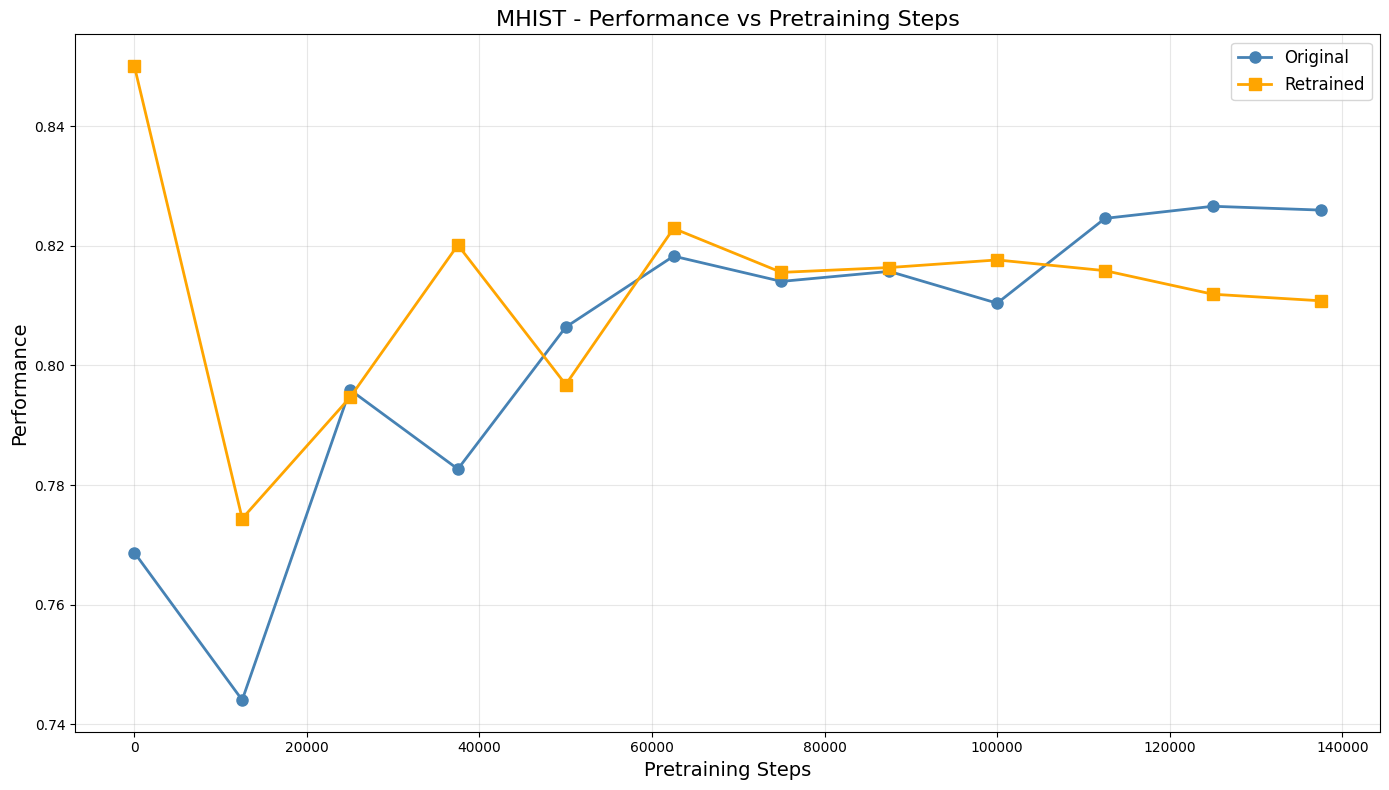

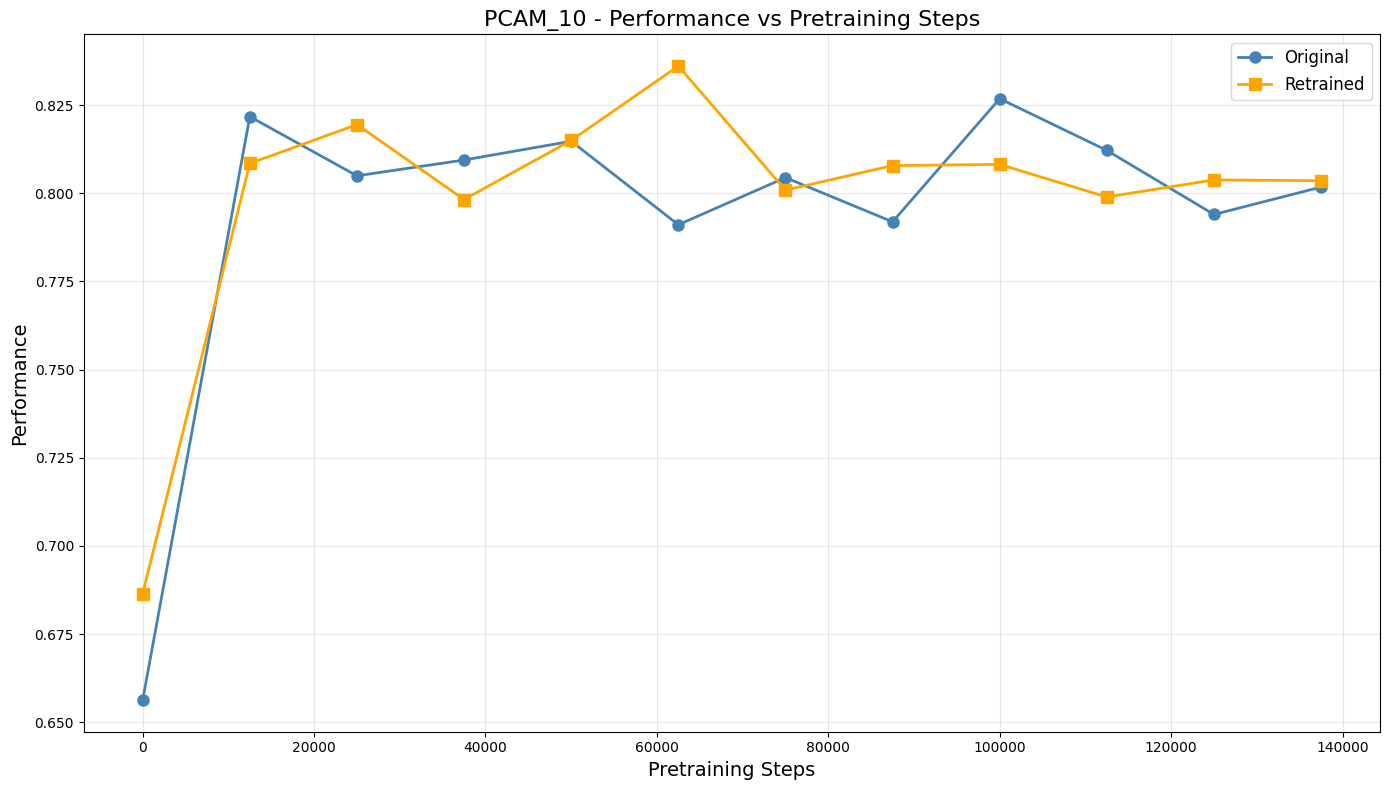

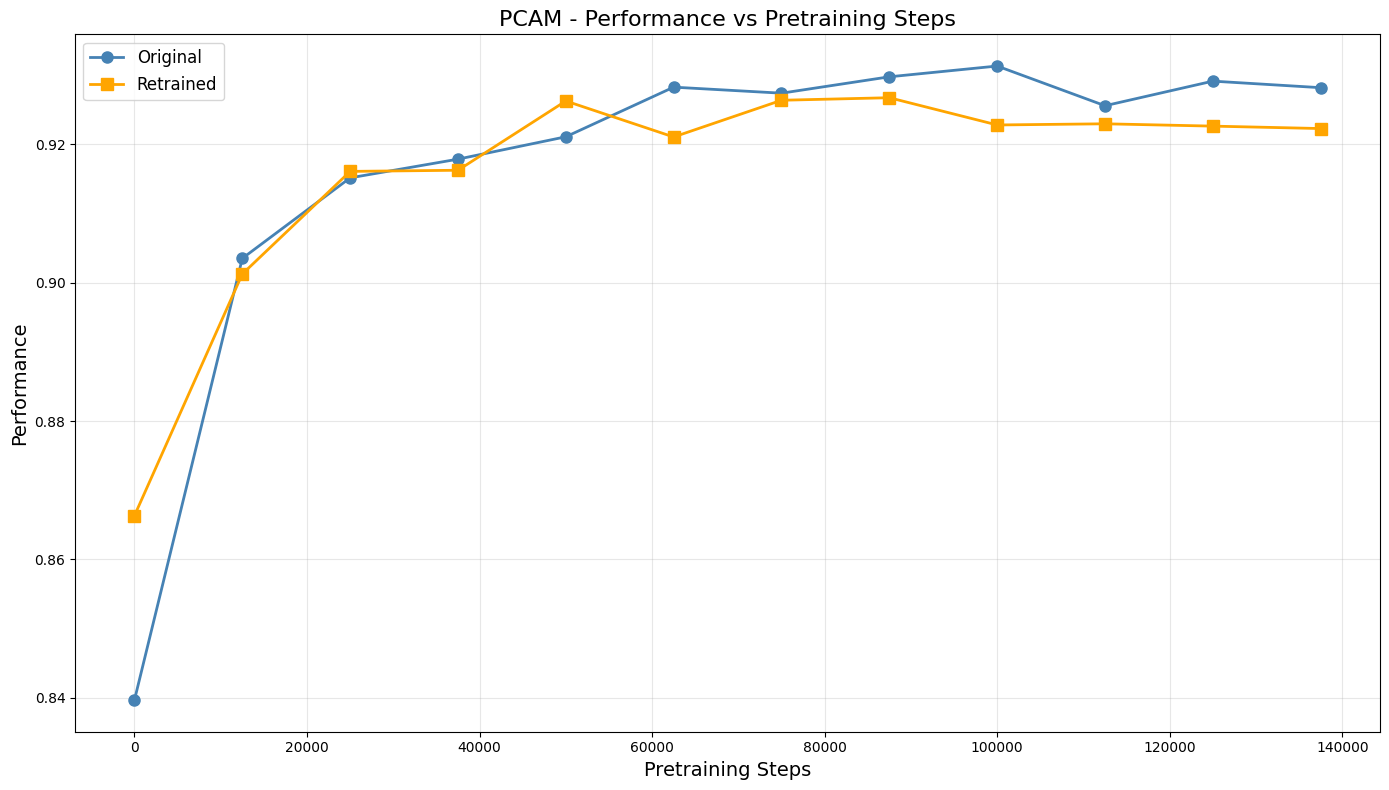

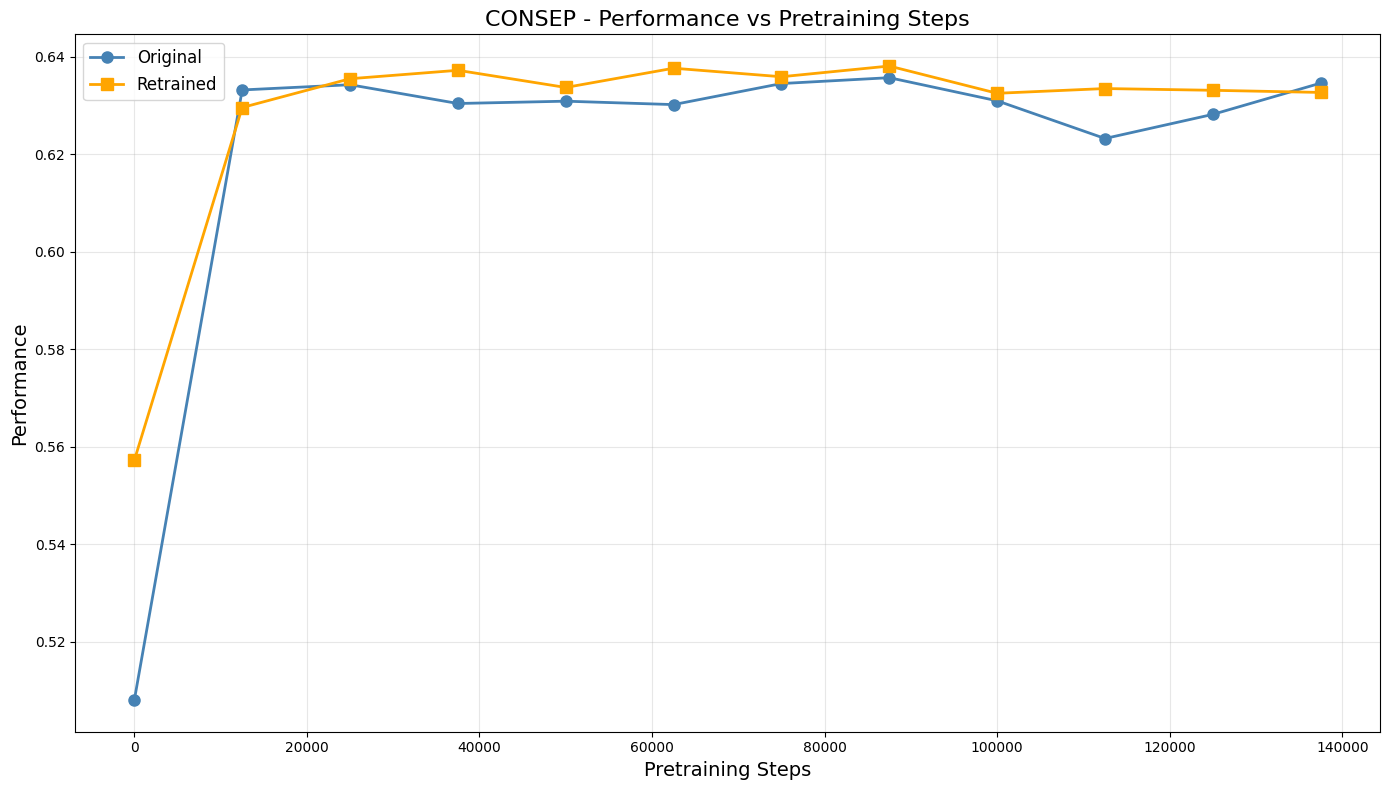

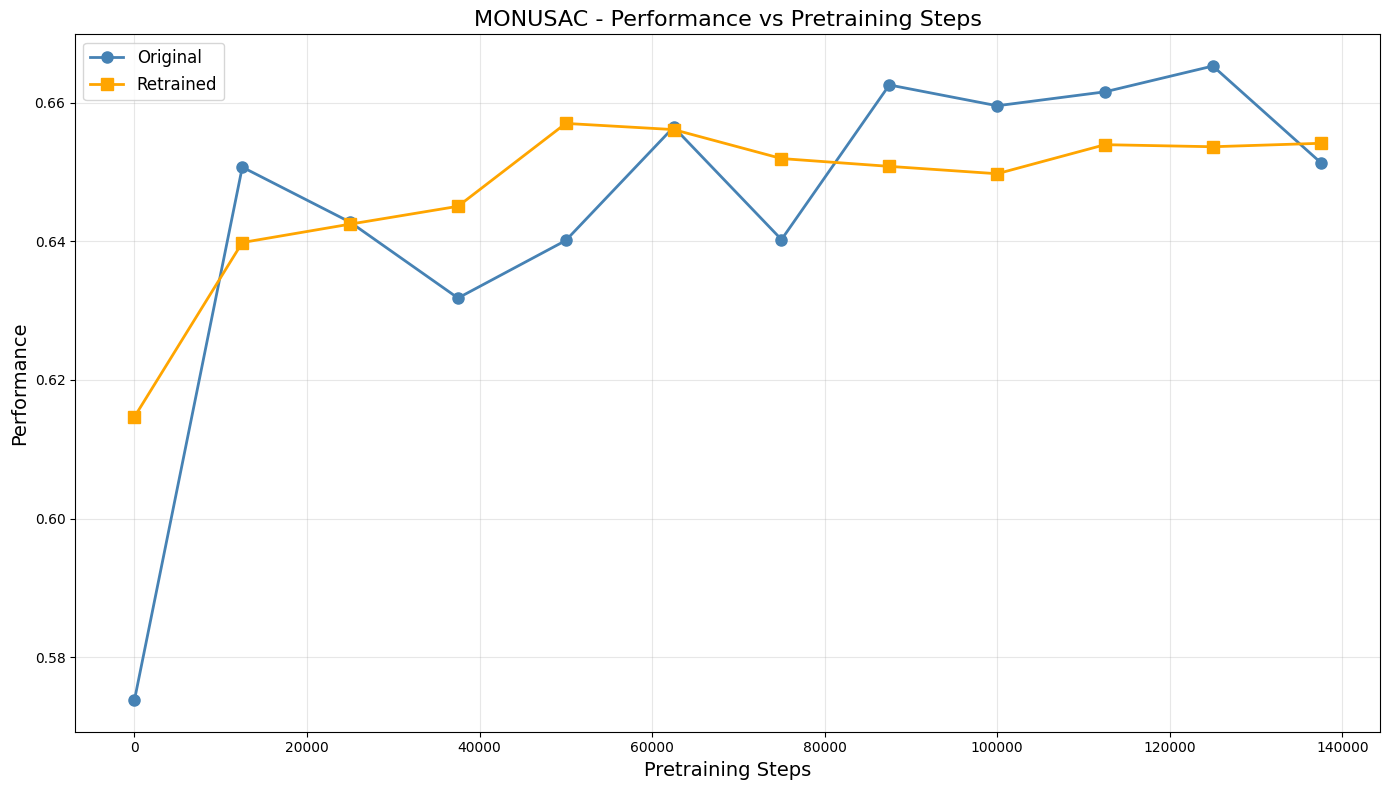

Saved 10 comparison plots


In [16]:
# Plot per-dataset comparison
individual_df = combined_df.dropna(subset=['metric_mean']).copy()
individual_df["step"] = individual_df["step"].astype(int)
individual_df = individual_df[individual_df["step"] <= 137500]  # Filter out steps greater than 137.5k
individual_df = individual_df.sort_values('step')
individual_df = individual_df.drop_duplicates(subset=["dataset", "step", "config"])

datasets = individual_df["dataset"].unique()

for dataset in datasets:
    dataset_data = individual_df[individual_df["dataset"] == dataset]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot original config
    og_data = dataset_data[dataset_data["config"] == "original"].sort_values("step")
    ax.plot(og_data["step"], og_data["metric_mean"], 
            marker='o', linewidth=2, markersize=8, 
            label='Original', color='steelblue')
    
    # Plot retrained config
    retrain_data = dataset_data[dataset_data["config"] == "retrained"].sort_values("step")
    ax.plot(retrain_data["step"], retrain_data["metric_mean"], 
            marker='s', linewidth=2, markersize=8, 
            label='Retrained', color='orange')
    
    ax.set_xlabel('Pretraining Steps', fontsize=14)
    ax.set_ylabel('Performance', fontsize=14)
    ax.set_title(f'{dataset.upper()} - Performance vs Pretraining Steps', 
                 fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(f'{dataset}_og_vs_retrained.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"Saved {len(datasets)} comparison plots")

In [17]:
# Check for any other failures
failed = combined_df[combined_df['status'] == 'fail']
print(f"Failed evaluations: {len(failed)}")
print(failed[['dataset', 'step', 'config', 'status']])

Failed evaluations: 0
Empty DataFrame
Columns: [dataset, step, config, status]
Index: []


In [18]:
# After filtering to 137.5K
consep_data = individual_df[individual_df['dataset'] == 'consep']
print(f"CoNSeP data points: {len(consep_data)}")
print(f"CoNSeP steps: {sorted(consep_data['step'].unique())}")
print(f"CoNSeP configs: {consep_data['config'].value_counts()}")

# Check original vs retrained
consep_og = consep_data[consep_data['config'] == 'original']
consep_rt = consep_data[consep_data['config'] == 'retrained']

print(f"\nOriginal CoNSeP:")
print(consep_og[['step', 'metric_mean']].sort_values('step'))

print(f"\nRetrained CoNSeP:")
print(consep_rt[['step', 'metric_mean']].sort_values('step'))

CoNSeP data points: 24
CoNSeP steps: [np.int64(0), np.int64(12500), np.int64(25000), np.int64(37500), np.int64(50000), np.int64(62500), np.int64(75000), np.int64(87500), np.int64(100000), np.int64(112500), np.int64(125000), np.int64(137500)]
CoNSeP configs: config
original     12
retrained    12
Name: count, dtype: int64

Original CoNSeP:
       step  metric_mean
8         0     0.508010
38    12500     0.633162
148   25000     0.634234
228   37500     0.630382
238   50000     0.630857
248   62500     0.630157
258   75000     0.634474
268   87500     0.635678
18   100000     0.630936
28   112500     0.623201
48   125000     0.628149
58   137500     0.634561

Retrained CoNSeP:
       step  metric_mean
278       0     0.557186
308   12500     0.629557
338   25000     0.635464
348   37500     0.637194
358   50000     0.633671
368   62500     0.637621
378   75000     0.635871
388   87500     0.638068
288  100000     0.632475
298  112500     0.633450
318  125000     0.633091
328  137500    

The End